# Train Model PM2.5, PM10, CO (XGBoost)

- PM2.5 → XGBoost  
- PM10 → XGBoost  
- CO → XGBoost  

PKL disimpan dengan nama baru (`_v2`) agar tidak menimpa file existing.

**Catatan:** Env vars `SUPABASE_URL` dan `SUPABASE_KEY` harus sudah di-set (atau ada di `.env`).

In [14]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from supabase import create_client, Client
import os
from datetime import datetime, timedelta
import joblib
from sklearn.metrics import mean_absolute_percentage_error

SUPABASE_URL = os.getenv("SUPABASE_URL", "")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

if not SUPABASE_URL or not SUPABASE_KEY:
    env_path = ".env"
    if os.path.exists(env_path):
        for line in open(env_path):
            if "=" in line and not line.startswith("#"):
                k, _, v = line.partition("=")
                os.environ[k.strip()] = v.strip().strip('"')
    SUPABASE_URL = os.getenv("SUPABASE_URL", "")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY", "")

SUPABASE_URL = SUPABASE_URL.replace("http://", "https://")
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print(f"Connected to {SUPABASE_URL}")

Connected to https://knpwncirbhcytssrxcqx.supabase.co


### 1. Ambil Data

In [15]:
TABLE = "tb_konsentrasi_gas"
days_back = 30
since = (datetime.now() - timedelta(days=days_back)).isoformat()

all_data = []
offset = 0
while True:
    resp = supabase.table(TABLE) \
        .select("pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity,created_at") \
        .gte("created_at", since) \
        .order("created_at", desc=False) \
        .range(offset, offset + 999) \
        .execute()
    batch = resp.data
    if not batch:
        break
    all_data.extend(batch)
    offset += len(batch)

df = pd.DataFrame(all_data)
for col in ["pm25_ugm3","pm10_ugm3","co_ugm3","no2_ugm3","o3_ugm3","temperature","humidity"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["created_at"] = pd.to_datetime(df["created_at"]).dt.tz_localize(None)
df = df.dropna(subset=["pm25_ugm3","pm10_ugm3","co_ugm3","temperature","humidity"])
df = df.set_index("created_at").sort_index()
df = df[~df.index.duplicated(keep="first")]
df.rename(columns={
    "pm25_ugm3": "pm25",
    "pm10_ugm3": "pm10",
    "co_ugm3": "co",
    "no2_ugm3": "no2",
    "o3_ugm3": "o3",
}, inplace=True)

print(f"Total: {len(df)} baris")
print(f"PM2.5: mean={df['pm25'].mean():.1f}, std={df['pm25'].std():.1f}")
print(f"PM10:  mean={df['pm10'].mean():.1f}, std={df['pm10'].std():.1f}")
print(f"CO:    mean={df['co'].mean():.1f}, std={df['co'].std():.1f}")

Total: 27111 baris
PM2.5: mean=15.9, std=3.2
PM10:  mean=17.7, std=4.5
CO:    mean=2865.9, std=555.9


### 2a. EDA & Uji Stasioneritas

Eksplorasi data dasar meliputi statistik deskriptif, visualisasi time series,
distribusi, boxplot per jam, uji stasioneritas (ADF), analisis autokorelasi
(ACF/PACF), korelasi antar fitur, rolling statistics, dan cross-correlation.

In [16]:
print("=== RINGKASAN STATISTIK ===")
print(df[["pm25","pm10","co","no2","o3","temperature","humidity"]].describe().round(2))
print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nRentang waktu: {df.index[0]} - {df.index[-1]}")
print(f"Total baris: {len(df)}")
print(f"Duplikat index: {df.index.duplicated().sum()}")

=== RINGKASAN STATISTIK ===
           pm25      pm10        co       no2        o3  temperature  humidity
count  27111.00  27111.00  27111.00  27111.00  27111.00     27111.00  27111.00
mean      15.89     17.70   2865.94      0.11     22.55        34.76     59.34
std        3.20      4.48    555.89      5.83     15.94         2.14      8.02
min        6.25      5.39    918.37      0.00      1.08        29.50     26.40
25%       14.01     15.14   2583.56      0.00     19.63        33.60     55.70
50%       15.42     17.00   2891.64      0.00     19.63        34.60     60.60
75%       17.18     19.56   3212.79      0.00     19.63        34.90     64.90
max      141.25    242.34   8237.73    309.59    140.42        47.60     98.00

=== MISSING VALUES ===
pm25           0
pm10           0
co             0
no2            0
o3             0
temperature    0
humidity       0
dtype: int64

Rentang waktu: 2026-05-16 22:13:29.348573 - 2026-06-15 15:12:49.506309
Total baris: 27111
Duplikat index

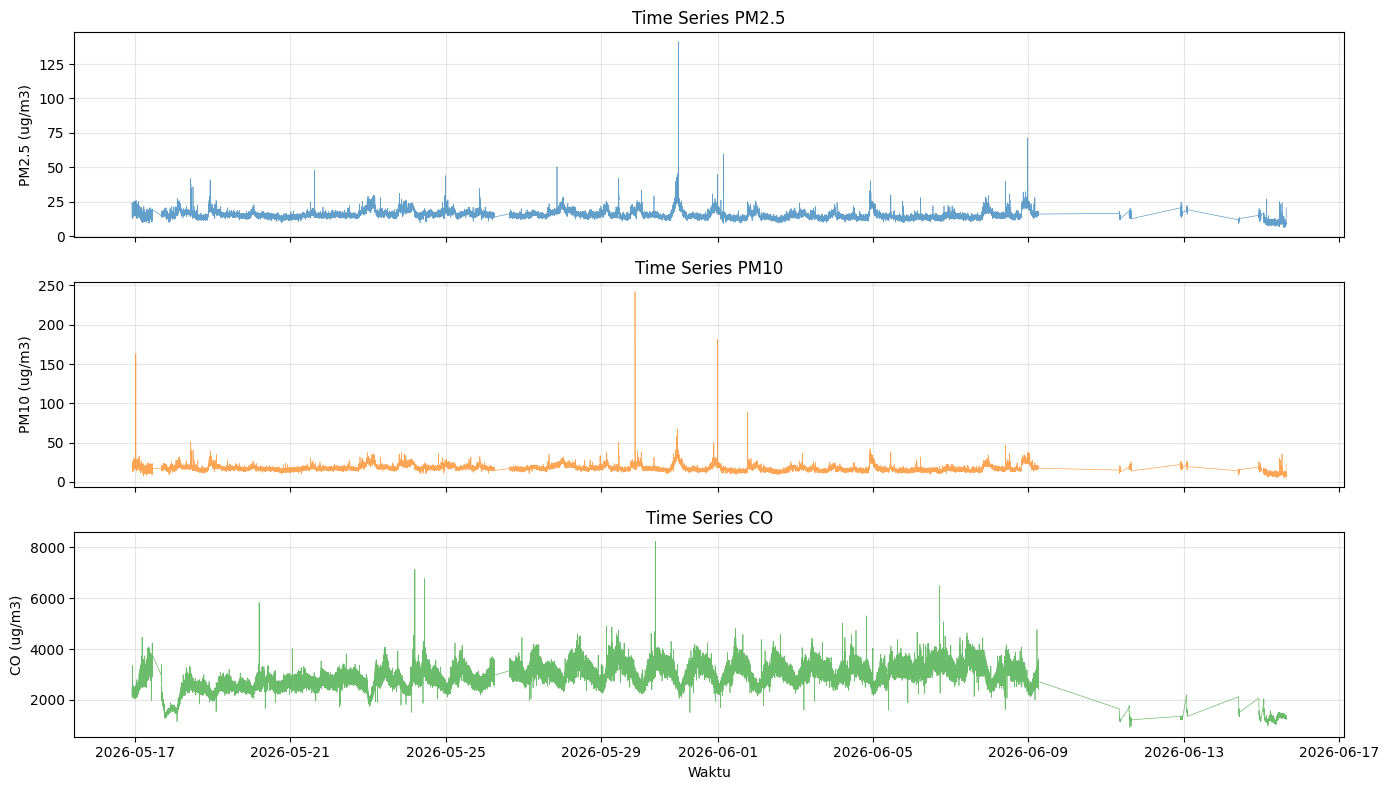

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df["pm25"], color="tab:blue", alpha=0.7, linewidth=0.5)
axes[0].set_ylabel("PM2.5 (ug/m3)")
axes[0].set_title("Time Series PM2.5")
axes[0].grid(alpha=0.3)
axes[1].plot(df.index, df["pm10"], color="tab:orange", alpha=0.7, linewidth=0.5)
axes[1].set_ylabel("PM10 (ug/m3)")
axes[1].set_title("Time Series PM10")
axes[1].grid(alpha=0.3)
axes[2].plot(df.index, df["co"], color="tab:green", alpha=0.7, linewidth=0.5)
axes[2].set_ylabel("CO (ug/m3)")
axes[2].set_title("Time Series CO")
axes[2].grid(alpha=0.3)
plt.xlabel("Waktu")
plt.tight_layout()
plt.show()

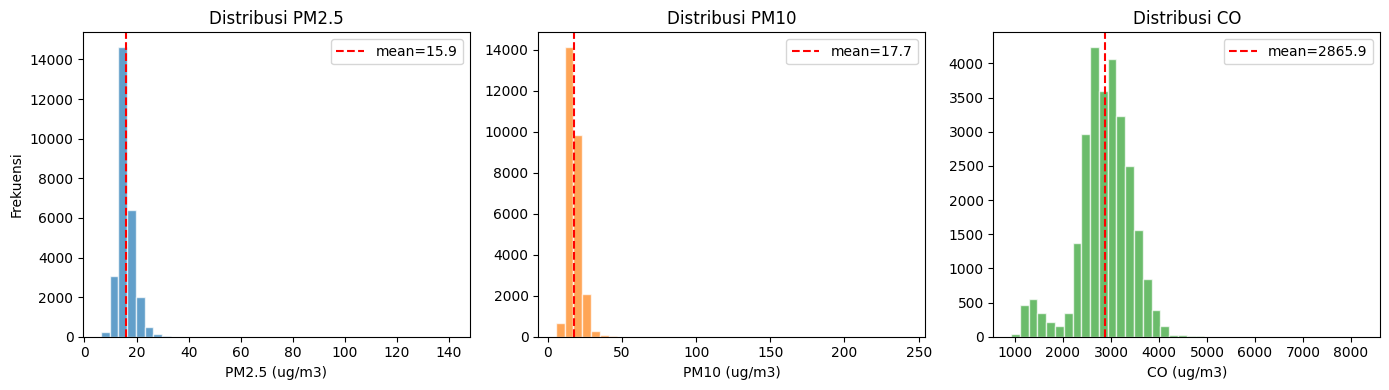

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df["pm25"], bins=40, color="tab:blue", edgecolor="white", alpha=0.7)
axes[0].set_xlabel("PM2.5 (ug/m3)")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi PM2.5")
axes[0].axvline(df["pm25"].mean(), color="red", ls="--", label=f"mean={df['pm25'].mean():.1f}")
axes[0].legend()
axes[1].hist(df["pm10"], bins=40, color="tab:orange", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("PM10 (ug/m3)")
axes[1].set_title("Distribusi PM10")
axes[1].axvline(df["pm10"].mean(), color="red", ls="--", label=f"mean={df['pm10'].mean():.1f}")
axes[1].legend()
axes[2].hist(df["co"], bins=40, color="tab:green", edgecolor="white", alpha=0.7)
axes[2].set_xlabel("CO (ug/m3)")
axes[2].set_title("Distribusi CO")
axes[2].axvline(df["co"].mean(), color="red", ls="--", label=f"mean={df['co'].mean():.1f}")
axes[2].legend()
plt.tight_layout()
plt.show()

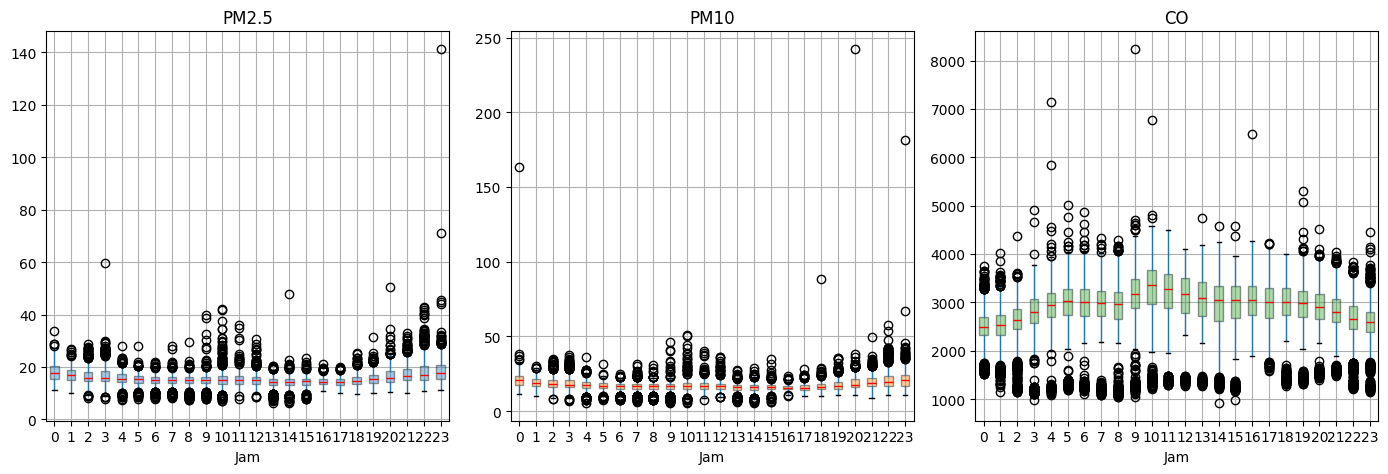

In [19]:
df_box = df.copy()
df_box["hour"] = df_box.index.hour
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, color, title in zip(axes, ["pm25","pm10","co"], ["tab:blue","tab:orange","tab:green"], ["PM2.5","PM10","CO"]):
    df_box.boxplot(column=col, by="hour", ax=ax, grid=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.4), medianprops=dict(color="red"))
    ax.set_title(title)
    ax.set_xlabel("Jam")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [20]:
from statsmodels.tsa.stattools import adfuller
print("=== UJI STASIONERITAS (ADF) ===\n")
for col in ["pm25", "pm10", "co"]:
    stat, pval, usedlag, nobs, crit, icbest = adfuller(df[col].dropna())
    msg = "STASIONER" if pval < 0.05 else "TIDAK STASIONER"
    print(f"{col.upper():6s} | ADF={stat:.4f} | p-value={pval:.6f} | {msg}")

=== UJI STASIONERITAS (ADF) ===

PM25   | ADF=-7.1627 | p-value=0.000000 | STASIONER
PM10   | ADF=-7.5050 | p-value=0.000000 | STASIONER
CO     | ADF=-3.5557 | p-value=0.006666 | STASIONER


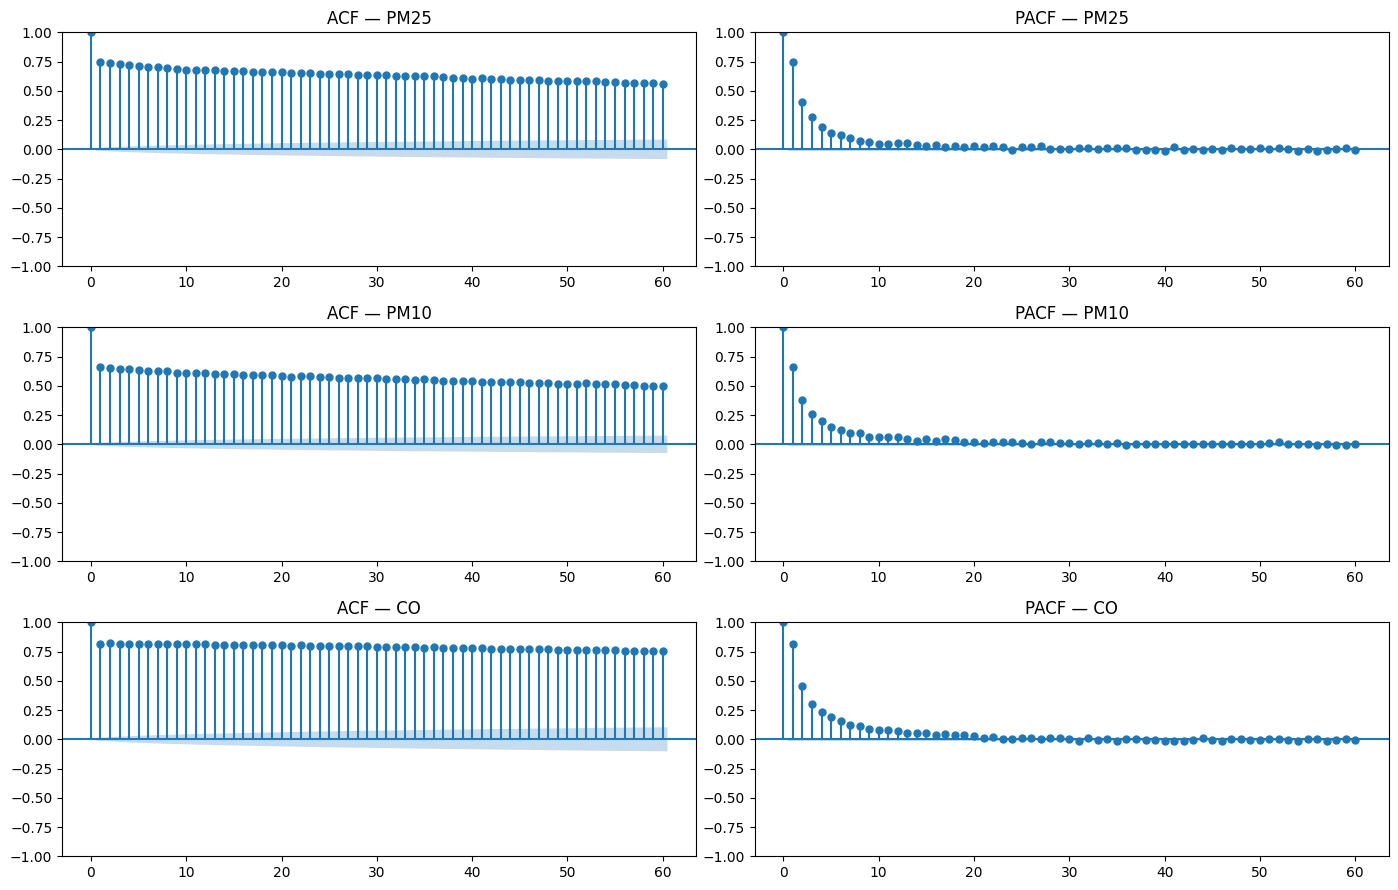

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
lags = 60
for i, col in enumerate(["pm25", "pm10", "co"]):
    plot_acf(df[col].dropna(), lags=lags, ax=axes[i,0])
    axes[i,0].set_title(f"ACF \u2014 {col.upper()}")
    plot_pacf(df[col].dropna(), lags=lags, ax=axes[i,1], method="ywm")
    axes[i,1].set_title(f"PACF \u2014 {col.upper()}")
plt.tight_layout()
plt.show()

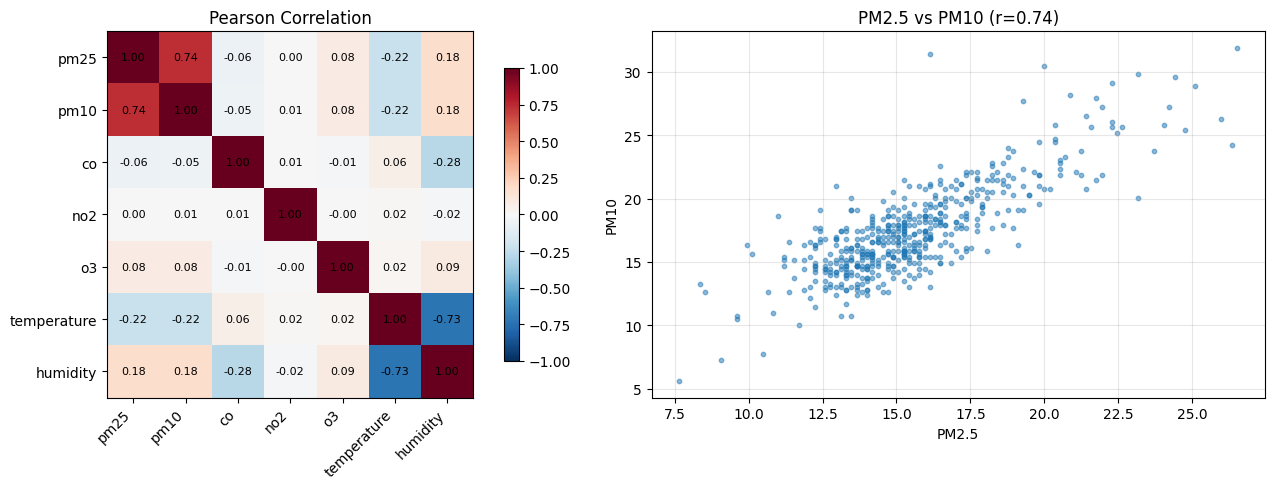

In [22]:
corr_cols = ["pm25","pm10","co","no2","o3","temperature","humidity"]
corr = df[corr_cols].corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_cols)))
axes[0].set_yticks(range(len(corr_cols)))
axes[0].set_xticklabels(corr_cols, rotation=45, ha="right")
axes[0].set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        axes[0].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
axes[0].set_title("Pearson Correlation")
plt.colorbar(im, ax=axes[0], shrink=0.8)

scatter = df[corr_cols].sample(min(500, len(df)))
axes[1].scatter(scatter["pm25"], scatter["pm10"], s=10, alpha=0.5, c="tab:blue")
axes[1].set_xlabel("PM2.5")
axes[1].set_ylabel("PM10")
axes[1].set_title(f"PM2.5 vs PM10 (r={corr.loc['pm25','pm10']:.2f})")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

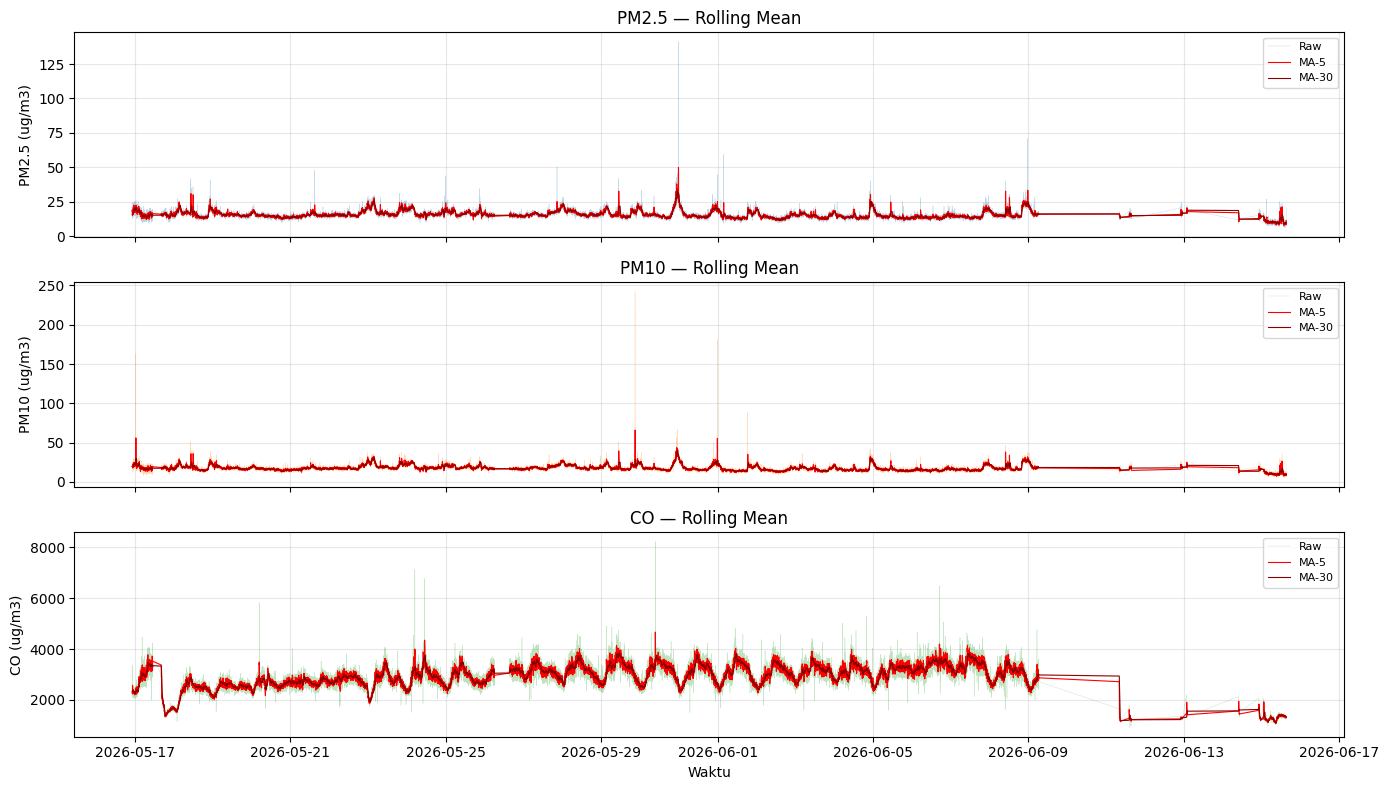

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, col, color, title in zip(axes, ["pm25","pm10","co"], ["tab:blue","tab:orange","tab:green"], ["PM2.5","PM10","CO"]):
    vals = df[col].dropna()
    roll_mean_5 = vals.rolling(5).mean()
    roll_mean_30 = vals.rolling(30).mean()
    ax.plot(vals.index, vals, alpha=0.3, linewidth=0.3, color=color, label="Raw")
    ax.plot(vals.index, roll_mean_5, linewidth=0.8, color="red", label="MA-5")
    ax.plot(vals.index, roll_mean_30, linewidth=0.8, color="darkred", label="MA-30")
    ax.set_ylabel(f"{title} (ug/m3)")
    ax.set_title(f"{title} \u2014 Rolling Mean")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.xlabel("Waktu")
plt.tight_layout()
plt.show()

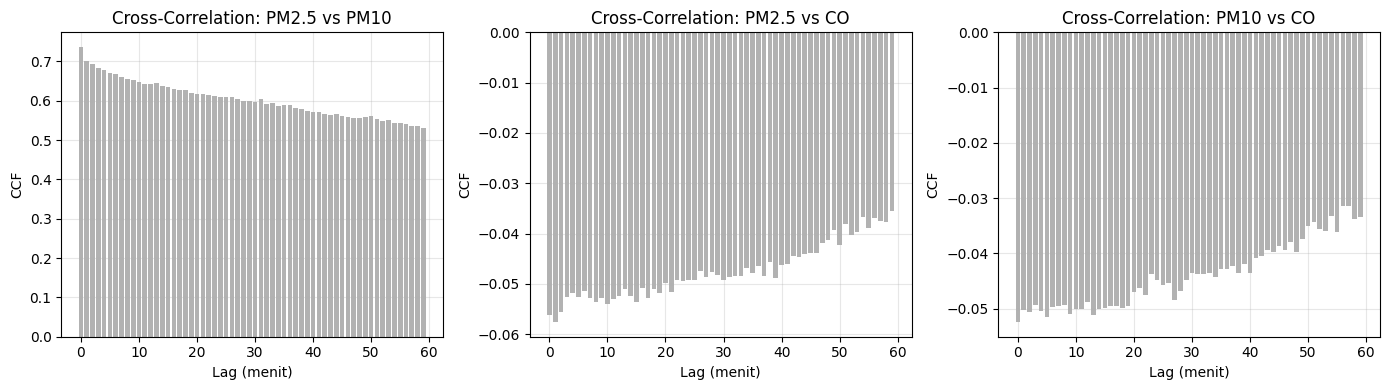

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
from statsmodels.tsa.stattools import ccf
for ax, (a, b, label) in zip(axes, [
    ("pm25","pm10","PM2.5 vs PM10"),
    ("pm25","co","PM2.5 vs CO"),
    ("pm10","co","PM10 vs CO"),
]):
    vals_a = df[a].dropna().values
    vals_b = df[b].dropna().values
    min_len = min(len(vals_a), len(vals_b))
    cc = ccf(vals_a[:min_len], vals_b[:min_len], adjusted=False)[:60]
    ax.bar(range(len(cc)), cc, width=0.8, color="gray", alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"Cross-Correlation: {label}")
    ax.set_xlabel("Lag (menit)")
    ax.set_ylabel("CCF")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Feature Engineering (identik minutes_xgb.ipynb)

In [25]:
RAW_COLS = ["pm25", "pm10", "co", "no2", "temperature", "humidity"]

feat = df.copy()

for col in RAW_COLS:
    if col not in feat.columns:
        continue
    feat[f"{col}_lag_1min"] = feat[col].shift(1)
    feat[f"{col}_lag_5min"] = feat[col].shift(5)
    feat[f"{col}_lag_15min"] = feat[col].shift(15)
    feat[f"{col}_lag_60min"] = feat[col].shift(60)
    feat[f"{col}_rolling_mean_5min"] = feat[col].rolling(window=5).mean()
    feat[f"{col}_rolling_std_5min"] = feat[col].rolling(window=5).std()
    feat[f"{col}_rolling_mean_15min"] = feat[col].rolling(window=15).mean()

feat["minute"] = feat.index.minute
feat["hour"] = feat.index.hour
feat["dayofweek"] = feat.index.dayofweek

print(f"Fitur: {len(feat.columns)} kolom")

Fitur: 52 kolom


### 3. Train & Evaluasi

In [26]:
TARGETS = {
    "pm25": {"model": XGBRegressor, "params": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "random_state": 42, "objective": "reg:squarederror", "verbosity": 0}, "pkl": "xgb_pm25_v2.pkl"},
    "pm10": {"model": XGBRegressor, "params": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "random_state": 42, "objective": "reg:squarederror", "verbosity": 0}, "pkl": "xgb_pm10_v2.pkl"},
    "co":   {"model": XGBRegressor, "params": {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "random_state": 42, "objective": "reg:squarederror", "verbosity": 0}, "pkl": "xgb_co_v2.pkl"},
}

FEATURE_COLS = [c for c in feat.columns if c not in ["pm25", "pm10", "co", "no2", "o3"]]
print(f"Feature cols: {len(FEATURE_COLS)}")

results = {}

for target_name, config in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"Training {config['model'].__name__} untuk {target_name.upper()}")
    print(f"{'='*60}")

    y = feat[target_name]
    X = feat[FEATURE_COLS].copy()

    split_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    model = config["model"](**config["params"])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    joblib.dump(model, config["pkl"])

    results[target_name] = {
        "model": config["model"].__name__,
        "pkl": config["pkl"],
        "mae": round(mae, 4),
        "rmse": round(rmse, 4),
        "r2": round(r2, 4),
        "mape": round(mape, 4),
        "train": len(X_train),
        "test": len(X_test),
    }

    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R2   : {r2:.4f} ({r2*100:.2f}%)")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  PKL  : {config['pkl']}")
    

print(f"\n{'='*60}")
print("RINGKASAN SEMUA MODEL")
print(f"{'='*60}")

for name, r in results.items():
    print(
        f"  {name.upper():6s} | "
        f"{r['model']:20s} | "
        f"R2={r['r2']:.4f} ({r['r2']*100:.1f}%) | "
        f"MAE={r['mae']:.4f} | "
        f"MAPE={r['mape']:.2f}% | "
        f"{r['pkl']}"
    )

Feature cols: 47

Training XGBRegressor untuk PM25
  MAE  : 1.0314
  RMSE : 1.5565
  R2   : 0.8008 (80.08%)
  MAPE : 7.50%
  PKL  : xgb_pm25_v2.pkl

Training XGBRegressor untuk PM10
  MAE  : 1.2992
  RMSE : 1.7802
  R2   : 0.8383 (83.83%)
  MAPE : 9.00%
  PKL  : xgb_pm10_v2.pkl

Training XGBRegressor untuk CO
  MAE  : 171.3699
  RMSE : 225.0601
  R2   : 0.9269 (92.69%)
  MAPE : 6.36%
  PKL  : xgb_co_v2.pkl

RINGKASAN SEMUA MODEL
  PM25   | XGBRegressor         | R2=0.8008 (80.1%) | MAE=1.0314 | MAPE=7.50% | xgb_pm25_v2.pkl
  PM10   | XGBRegressor         | R2=0.8383 (83.8%) | MAE=1.2992 | MAPE=9.00% | xgb_pm10_v2.pkl
  CO     | XGBRegressor         | R2=0.9269 (92.7%) | MAE=171.3699 | MAPE=6.36% | xgb_co_v2.pkl


### 4. Quick Test Prediksi

In [27]:
feat_test = feat.dropna().iloc[[-1]]
X_row = feat_test[FEATURE_COLS]

print(f"\nNilai aktual saat ini:")
print(f"  PM2.5 : {feat_test['pm25'].values[0]:.1f} ug/m3")
print(f"  PM10  : {feat_test['pm10'].values[0]:.1f} ug/m3")
print(f"  CO    : {feat_test['co'].values[0]:.1f} ug/m3")

print(f"\nPrediksi 1 menit ke depan:")
for target_name, config in TARGETS.items():
    model = joblib.load(config["pkl"])
    pred = float(model.predict(X_row.values)[0])
    actual = feat_test[target_name].values[0]
    print(f"  {target_name.upper():6s} : {pred:.1f} (actual: {actual:.1f})")


Nilai aktual saat ini:
  PM2.5 : 20.7 ug/m3
  PM10  : 21.9 ug/m3
  CO    : 1274.8 ug/m3

Prediksi 1 menit ke depan:
  PM25   : 13.1 (actual: 20.7)
  PM10   : 10.7 (actual: 21.9)
  CO     : 1276.4 (actual: 1274.8)
